In [1]:
import pandas as pd
from google.colab import drive

# 1. Mount and Load (Using your successful path)
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/Assignment 4 /q3_retail_promotions.csv'
df = pd.read_csv(file_path)

# 2. Convert to datetime object
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# 3. Extract Features
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek # Monday=0, Sunday=6

# 4. Create is_month_end (1 if day >= 25, else 0)
df['is_month_end'] = df['transaction_date'].dt.day.apply(lambda x: 1 if x >= 25 else 0)

# Display sample to confirm
print("Date features extracted:")
display(df[['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end']].head())

Mounted at /content/drive
Date features extracted:


,transaction_date,year,month,day_of_week,is_month_end
0,2022-01-01,2022,1,5,0
1,2022-01-01,2022,1,5,0
2,2022-01-02,2022,1,6,0
3,2022-01-02,2022,1,6,0
4,2022-01-03,2022,1,0,0


In [2]:
# 1. Sort by date
df = df.sort_values('transaction_date')

# 2. Split (80% Train, 20% Test)
split_point = int(len(df) * 0.8)
train_df = df.iloc[:split_point]
test_df = df.iloc[split_point:]

# 3. Separate Features and Target
# Drop the date column as models can't handle raw date strings
X_train = train_df.drop(['items_sold', 'transaction_date'], axis=1)
y_train = train_df['items_sold']
X_test = test_df.drop(['items_sold', 'transaction_date'], axis=1)
y_test = test_df['items_sold']

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 960
Testing set size: 240


In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Define which columns are categorical and which are numerical
cat_cols = ['promotion_type', 'location_type', 'store_size']
num_cols = ['store_id', 'competition_density', 'is_weekend', 'is_festival',
            'year', 'month', 'day_of_week', 'is_month_end']

# Create the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

print("Pipeline preprocessor defined successfully.")

Pipeline preprocessor defined successfully.


In [6]:
import matplotlib.pyplot as plt


--- Linear Regression ---
RMSE: 27.12
MAE: 21.05


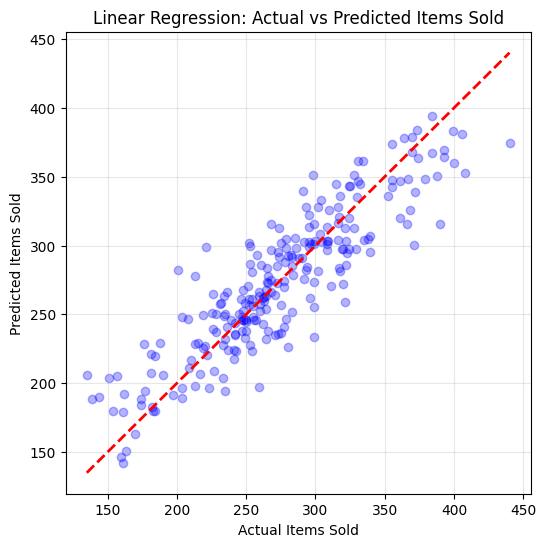


--- Random Forest ---
RMSE: 30.76
MAE: 24.24


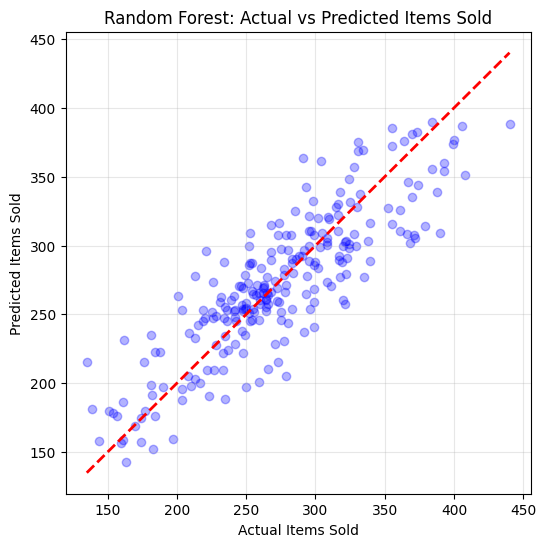


--- Top 5 Most Influential Features ---


,Feature,Importance
3,is_festival,0.173356
18,store_size_small,0.166052
15,location_type_urban,0.108783
6,day_of_week,0.078710
2,is_weekend,0.068935


In [7]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Create the full Pipelines
lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', LinearRegression())])
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', RandomForestRegressor(random_state=42))])

# 2. Train and Evaluate
for name, pipe in [("Linear Regression", lr_pipeline), ("Random Forest", rf_pipeline)]:
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)

    print(f"\n--- {name} ---")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")

    # Parity Plot
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test, preds, alpha=0.3, color='blue')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.title(f'{name}: Actual vs Predicted Items Sold')
    plt.xlabel('Actual Items Sold')
    plt.ylabel('Predicted Items Sold')
    plt.grid(True, alpha=0.3)
    plt.show()

# 3. Feature Importance (Specific Task for Random Forest)
# Get feature names after One-Hot Encoding
ohe_feature_names = rf_pipeline.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(cat_cols)
all_feature_names = num_cols + list(ohe_feature_names)

# Get importances from the Random Forest model inside the pipeline
importances = rf_pipeline.named_steps['regressor'].feature_importances_
feat_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

print("\n--- Top 5 Most Influential Features ---")
display(feat_df.head(5))